# **E-Commerce Customer Analytics**
### **Feature Engineering**

**Dataset:** UCI Online Retail Dataset  
**Notebook:** 03 of 06  
**Goal:** Transform the cleaned transaction-level data into a customer-level table.

**Import Libraries and Setup**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

os.makedirs("/content/outputs/charts", exist_ok=True)
os.makedirs("/content/data/processed", exist_ok=True)

In [4]:
# Load Cleaned Data
df = pd.read_csv("online_retail_cleaned.csv", parse_dates=["InvoiceDate"])

In [5]:
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")

Loaded: 349227 rows × 9 columns
Date range: 2010-12-01 to 2011-12-09


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


**Set the Reference Date**

The reference date is the anchor point for all recency calculations. We use the most recent transaction date in the dataset. Every "days since last purchase" figure is calculated relative to this date.

We add one day to the maximum date so that the most recent customer does not get a recency of zero.

In [7]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(f"Reference date: {reference_date.date()}")

Reference date: 2011-12-10


**Build the RFM Table**


- **Recency** - How many days since the customer last purchased.
- **Frequency** - How many orders has the customer placed in total.
- **Monetary** - How much has the customer spent in total.

We calculate all three per customer.

In [8]:
rfm = df.groupby("CustomerID").agg(
    Recency    = ("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency  = ("InvoiceNo",   "nunique"),
    Monetary   = ("TotalPrice",  "sum")
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12747,2,11,4196.01
2,12748,1,210,33053.19
3,12749,4,5,4090.88
4,12820,3,4,942.34


In [9]:
print(f"Customer table shape: {rfm.shape[0]} customers × {rfm.shape[1]} columns")

Customer table shape: 3921 customers × 4 columns


In [10]:
# Add features

extra = df.groupby("CustomerID").agg(
    FirstPurchaseDate = ("InvoiceDate", "min"),
    LastPurchaseDate  = ("InvoiceDate", "max"),
    TotalOrders       = ("InvoiceNo",   "nunique"),
    TotalSpend        = ("TotalPrice",  "sum")
).reset_index()

extra.head()

,CustomerID,FirstPurchaseDate,LastPurchaseDate,TotalOrders,TotalSpend
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60
1,12747,2010-12-05 15:38:00,2011-12-07 14:34:00,11,4196.01
2,12748,2010-12-01 12:48:00,2011-12-09 12:20:00,210,33053.19
3,12749,2011-05-10 15:25:00,2011-12-06 09:56:00,5,4090.88
4,12820,2011-01-17 12:34:00,2011-12-06 15:12:00,4,942.34


In [11]:
extra["AverageOrderValue"] = (extra["TotalSpend"] / extra["TotalOrders"]).round(2)
extra["TenureDays"]        = (extra["LastPurchaseDate"] - extra["FirstPurchaseDate"]).dt.days

extra.head()

,CustomerID,FirstPurchaseDate,LastPurchaseDate,TotalOrders,TotalSpend,AverageOrderValue,TenureDays
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,77183.60,0
1,12747,2010-12-05 15:38:00,2011-12-07 14:34:00,11,4196.01,381.46,366
2,12748,2010-12-01 12:48:00,2011-12-09 12:20:00,210,33053.19,157.40,372
3,12749,2011-05-10 15:25:00,2011-12-06 09:56:00,5,4090.88,818.18,209
4,12820,2011-01-17 12:34:00,2011-12-06 15:12:00,4,942.34,235.58,323


In [12]:
# Merge into RFM table
customer_df = rfm.merge(
    extra[["CustomerID", "FirstPurchaseDate", "LastPurchaseDate", "AverageOrderValue", "TenureDays"]],
    on="CustomerID"
)

print(f"Customer table shape: {customer_df.shape[0]} customers × {customer_df.shape[1]} columns")
customer_df.head()

Customer table shape: 3921 customers × 8 columns


,CustomerID,Recency,Frequency,Monetary,FirstPurchaseDate,LastPurchaseDate,AverageOrderValue,TenureDays
0,12346,326,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.60,0
1,12747,2,11,4196.01,2010-12-05 15:38:00,2011-12-07 14:34:00,381.46,366
2,12748,1,210,33053.19,2010-12-01 12:48:00,2011-12-09 12:20:00,157.40,372
3,12749,4,5,4090.88,2011-05-10 15:25:00,2011-12-06 09:56:00,818.18,209
4,12820,3,4,942.34,2011-01-17 12:34:00,2011-12-06 15:12:00,235.58,323


**Define and Create the Churn Label**

We define churn using a **90-day recency threshold:**

- `Churned = 1` - last purchase was more than 90 days ago
- `Churned = 0` - last purchase was within the last 90 days

In [13]:
churn_threshold = 90

customer_df["Churned"] = (customer_df["Recency"] > churn_threshold).astype(int)

In [14]:
customer_df.head()

,CustomerID,Recency,Frequency,Monetary,FirstPurchaseDate,LastPurchaseDate,AverageOrderValue,TenureDays,Churned
0,12346,326,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.60,0,1
1,12747,2,11,4196.01,2010-12-05 15:38:00,2011-12-07 14:34:00,381.46,366,0
2,12748,1,210,33053.19,2010-12-01 12:48:00,2011-12-09 12:20:00,157.40,372,0
3,12749,4,5,4090.88,2011-05-10 15:25:00,2011-12-06 09:56:00,818.18,209,0
4,12820,3,4,942.34,2011-01-17 12:34:00,2011-12-06 15:12:00,235.58,323,0


In [15]:
churn_counts = customer_df["Churned"].value_counts()
churn_pct    = customer_df["Churned"].value_counts(normalize=True) * 100

print(f"Active  (0): {churn_counts[0]} customers ({churn_pct[0]:.1f}%)")
print(f"Churned (1): {churn_counts[1]} customers ({churn_pct[1]:.1f}%)")

Active  (0): 2614 customers (66.7%)
Churned (1): 1307 customers (33.3%)


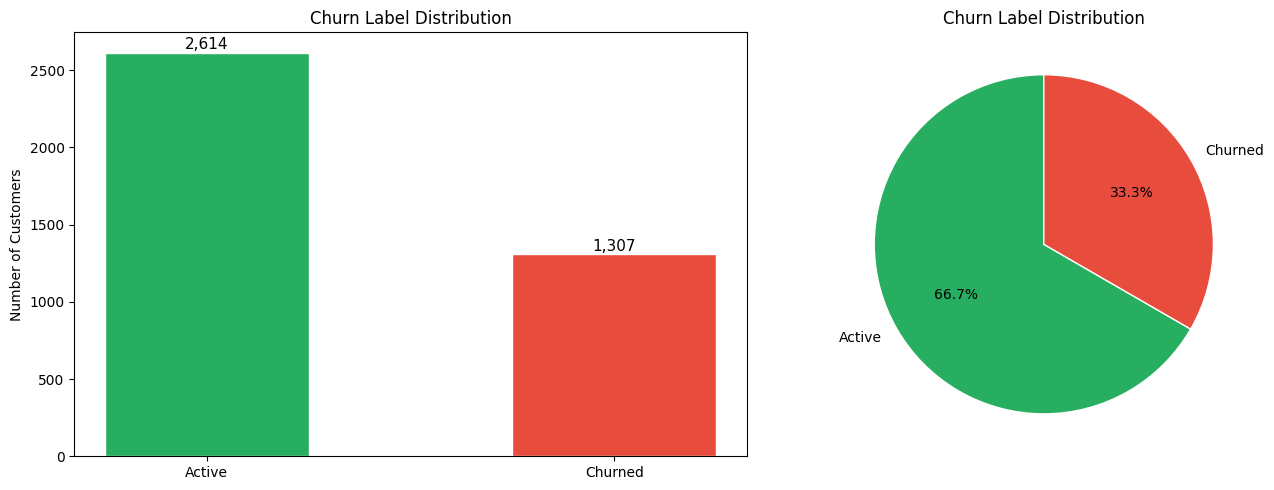

In [16]:
# Churn Split
labels = ["Active", "Churned"]
sizes  = [churn_counts[0], churn_counts[1]]
colors = ["#27ae60", "#e74c3c"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(labels, sizes, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Churn Label Distribution")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(sizes):
    axes[0].text(i, v + 20, f"{v:,}", ha="center", fontsize=11)

# Pie chart
axes[1].pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Churn Label Distribution")

plt.tight_layout()
plt.savefig("/content/outputs/charts/07_churn_distribution.png", dpi=150)
plt.show()

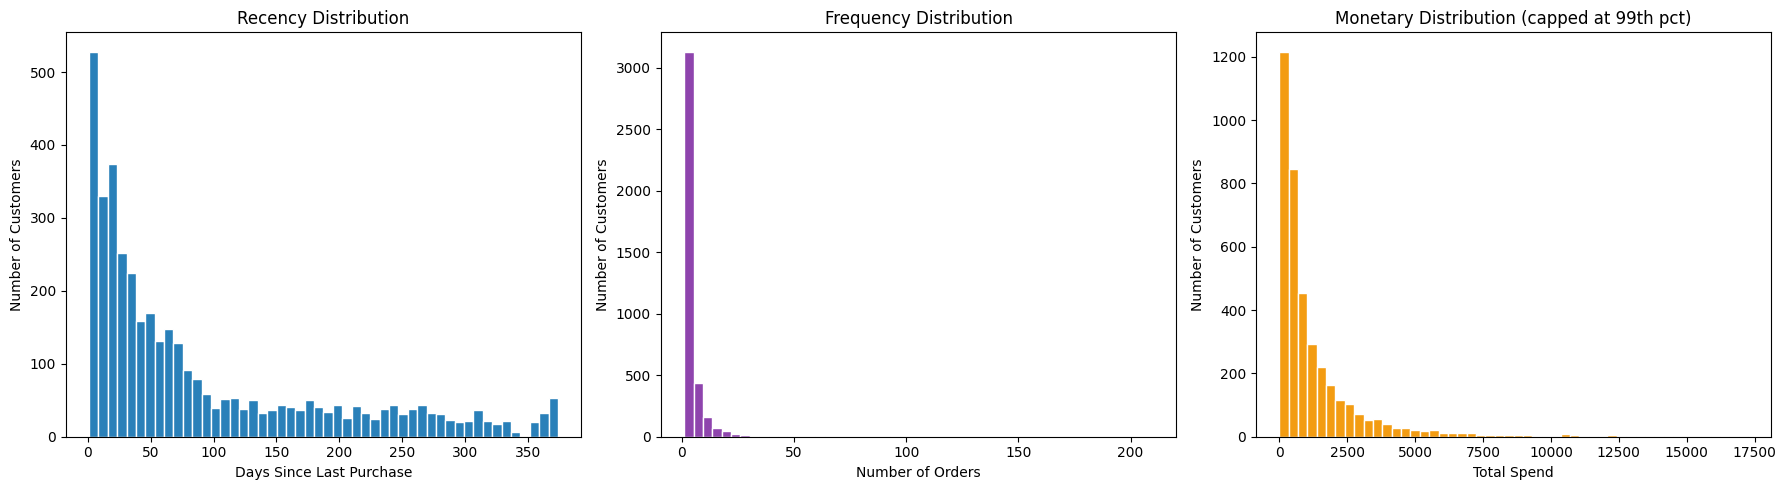

Chart saved.


In [17]:
# RFM Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency
axes[0].hist(customer_df["Recency"], bins=50, color="#2980b9", edgecolor="white")
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days Since Last Purchase")
axes[0].set_ylabel("Number of Customers")

# Frequency
axes[1].hist(customer_df["Frequency"], bins=50, color="#8e44ad", edgecolor="white")
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("Number of Customers")

# Monetary
m99 = customer_df["Monetary"].quantile(0.99)
axes[2].hist(
    customer_df[customer_df["Monetary"] <= m99]["Monetary"],
    bins=50, color="#f39c12", edgecolor="white"
)
axes[2].set_title("Monetary Distribution (capped at 99th pct)")
axes[2].set_xlabel("Total Spend")
axes[2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("/content/outputs/charts/08_rfm_distributions.png", dpi=150)
plt.show()
print("Chart saved.")

In [18]:
# RFM Averages by Churn Status

rfm_by_churn = customer_df.groupby("Churned")[["Recency", "Frequency", "Monetary"]].mean().round(2)
print(rfm_by_churn)

         Recency  Frequency  Monetary
Churned                              
0          31.77       5.43   2443.94
1         213.02       1.88    685.98


In [19]:
rfm_by_churn.index = ["Active", "Churned"]

print(rfm_by_churn)

         Recency  Frequency  Monetary
Active     31.77       5.43   2443.94
Churned   213.02       1.88    685.98


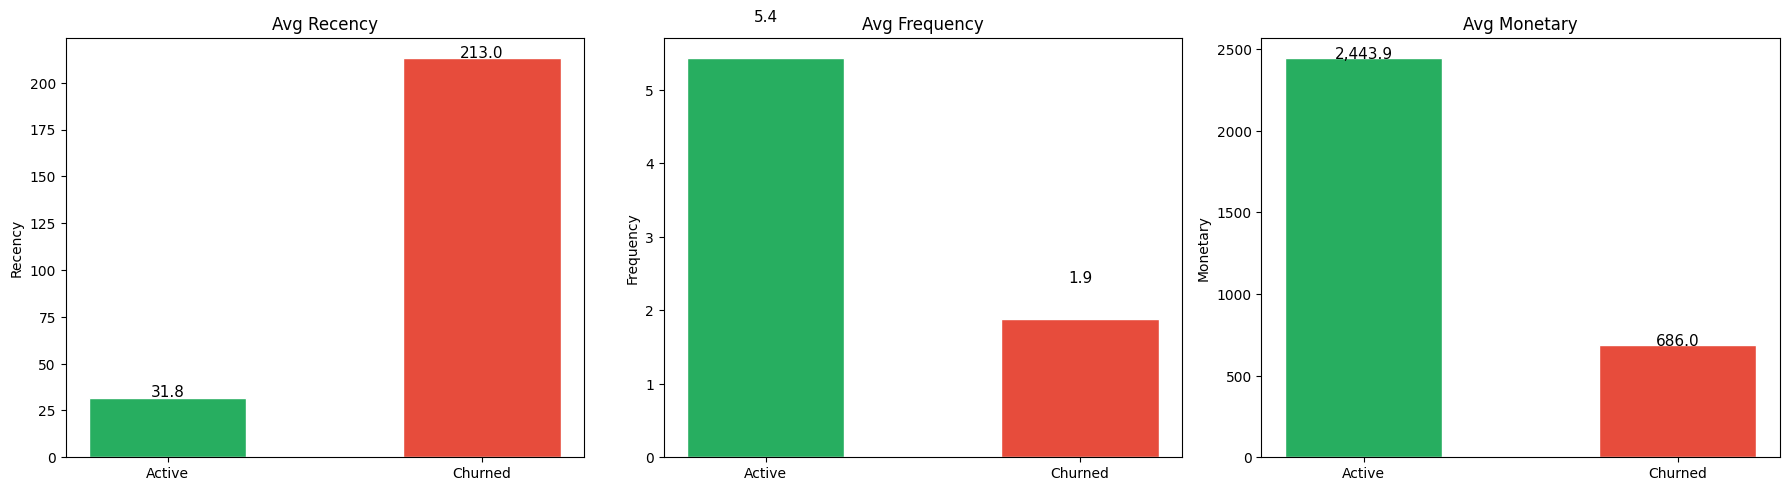

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["#27ae60", "#e74c3c"]
metrics = ["Recency", "Frequency", "Monetary"]
titles  = [
    "Avg Recency",
    "Avg Frequency",
    "Avg Monetary"
]

for i, (metric, title) in enumerate(zip(metrics, titles)):
    axes[i].bar(["Active", "Churned"], rfm_by_churn[metric], color=colors,
                edgecolor="white", width=0.5)
    axes[i].set_title(title)
    axes[i].set_ylabel(metric)
    for j, v in enumerate(rfm_by_churn[metric]):
        axes[i].text(j, v + 0.5, f"{v:,.1f}", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("/content/outputs/charts/09_rfm_by_churn.png", dpi=150)
plt.show()

In [25]:
customer_df.head()

,CustomerID,Recency,Frequency,Monetary,FirstPurchaseDate,LastPurchaseDate,AverageOrderValue,TenureDays,Churned
0,12346,326,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.60,0,1
1,12747,2,11,4196.01,2010-12-05 15:38:00,2011-12-07 14:34:00,381.46,366,0
2,12748,1,210,33053.19,2010-12-01 12:48:00,2011-12-09 12:20:00,157.40,372,0
3,12749,4,5,4090.88,2011-05-10 15:25:00,2011-12-06 09:56:00,818.18,209,0
4,12820,3,4,942.34,2011-01-17 12:34:00,2011-12-06 15:12:00,235.58,323,0


In [22]:
customer_df.shape

(3921, 9)

In [23]:
print(f"Customer Table Columns: {list(customer_df.columns)}")

Customer Table Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'FirstPurchaseDate', 'LastPurchaseDate', 'AverageOrderValue', 'TenureDays', 'Churned']


In [24]:
# Save Customer Table
output_path = "/content/data/processed/customer_features.csv"
customer_df.to_csv(output_path, index=False)